In [ ]:
# House Price Prediction Project
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [ ]:
# Create Sample House Price Data
np.random.seed(42)

# Create dataset
n_houses = 200

data = {
    'square_feet': np.random.uniform(1000, 5000, n_houses),
    'bedrooms': np.random.randint(1, 6, n_houses),
    'bathrooms': np.random.uniform(1, 4, n_houses),
    'age_years': np.random.randint(0, 50, n_houses),
    'latitude': np.random.uniform(40.7, 40.9, n_houses),
    'longitude': np.random.uniform(-74.0, -73.9, n_houses),
    'garage_spaces': np.random.randint(0, 4, n_houses),
}

# Create price based on features
price = (
    150 * data['square_feet'] +
    50000 * data['bedrooms'] +
    30000 * data['bathrooms'] +
    -1000 * data['age_years'] +
    500000
)

price = price + np.random.normal(0, 100000, n_houses)
price = np.maximum(price, 100000)

data['price'] = price
df = pd.DataFrame(data)

print(f"✅ Dataset created with {len(df)} houses")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Price range: ${df['price'].min():,.0f} - ${df['price'].max():,.0f}")

✅ Dataset created with 200 houses

First 5 rows:
   square_feet  bedrooms  bathrooms  age_years   latitude  longitude  \
0  2498.160475         4   3.883572         29  40.853556 -73.959361   
1  4802.857226         3   3.716052         14  40.717458 -73.967601   
2  3927.975767         1   1.587373         26  40.801221 -73.991307   
3  3394.633937         4   1.208084         33  40.886403 -73.936676   
4  1624.074562         4   1.302334         37  40.764128 -73.926410   

   garage_spaces         price  
0              0  1.364271e+06  
1              1  1.393923e+06  
2              0  9.903089e+05  
3              0  1.350728e+06  
4              1  1.059342e+06  

Dataset shape: (200, 8)
Price range: $739,051 - $1,690,572


DATA SUMMARY
       square_feet    bedrooms   bathrooms   age_years    latitude  \
count   200.000000  200.000000  200.000000  200.000000  200.000000   
mean   2936.024933    3.035000    2.599089   23.730000   40.803313   
std    1179.565725    1.440189    0.937223   14.568056    0.054445   
min    1022.088468    1.000000    1.032513    0.000000   40.700542   
25%    1914.329659    2.000000    1.840203   11.000000   40.759642   
50%    2977.945013    3.000000    2.679013   24.000000   40.806953   
75%    4027.438464    4.000000    3.439374   36.000000   40.850523   
max    4947.547746    5.000000    3.999153   49.000000   40.899539   

        longitude  garage_spaces         price  
count  200.000000     200.000000  2.000000e+02  
mean   -73.948776       1.435000  1.153019e+06  
std      0.029227       1.141178  2.146251e+05  
min    -73.999976       0.000000  7.390509e+05  
25%    -73.972876       0.000000  9.904043e+05  
50%    -73.947813       1.000000  1.154486e+06  
75%    -73.92

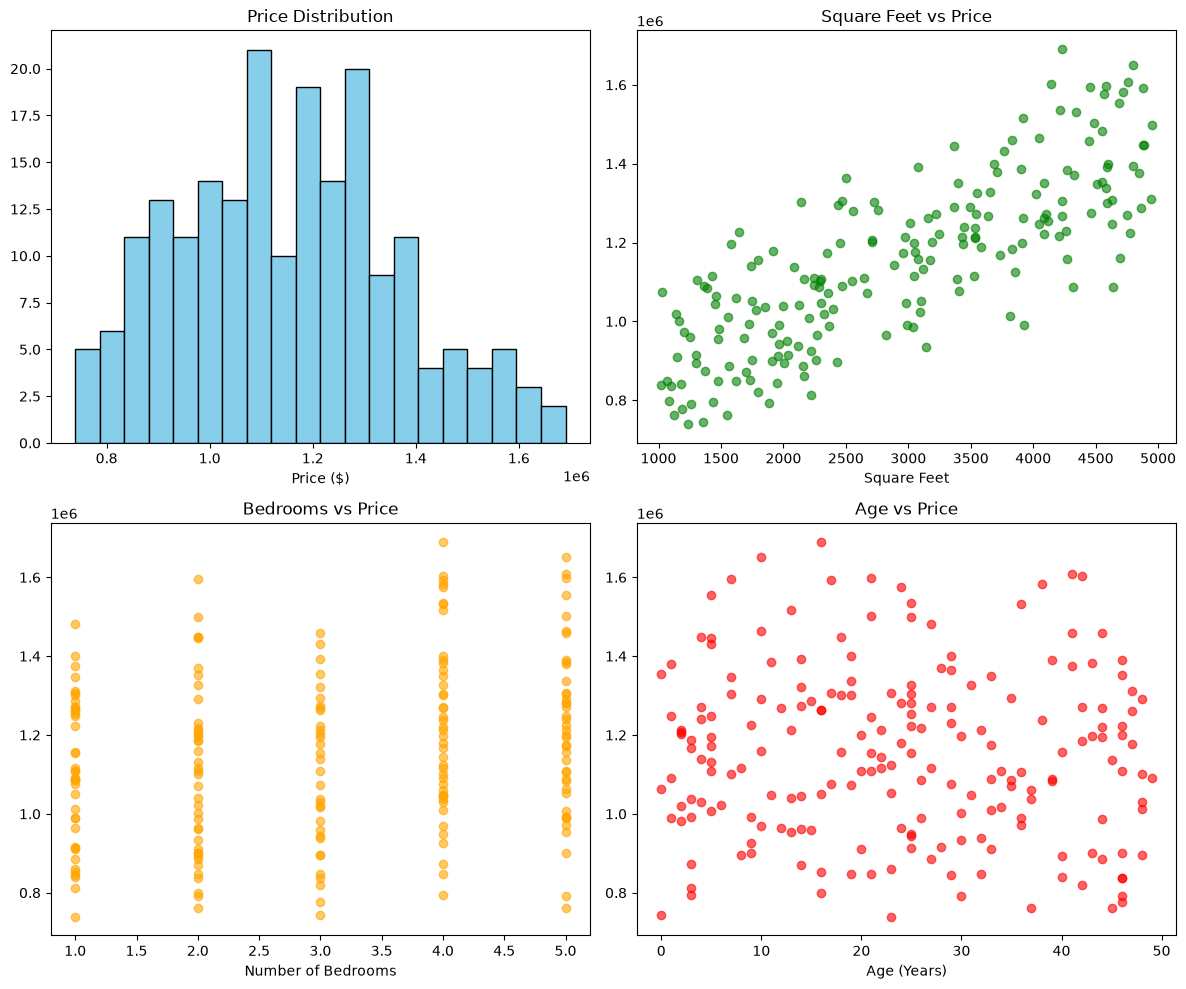


✅ EDA Complete!


In [ ]:
# Exploratory Data Analysis (EDA)

print("=" * 50)
print("DATA SUMMARY")
print("=" * 50)
print(df.describe())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("CORRELATION WITH PRICE")
print("=" * 50)
correlation = df.corr()['price'].sort_values(ascending=False)
print(correlation)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(df['price'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')

axes[0, 1].scatter(df['square_feet'], df['price'], alpha=0.6, color='green')
axes[0, 1].set_title('Square Feet vs Price')
axes[0, 1].set_xlabel('Square Feet')

axes[1, 0].scatter(df['bedrooms'], df['price'], alpha=0.6, color='orange')
axes[1, 0].set_title('Bedrooms vs Price')
axes[1, 0].set_xlabel('Number of Bedrooms')

axes[1, 1].scatter(df['age_years'], df['price'], alpha=0.6, color='red')
axes[1, 1].set_title('Age vs Price')
axes[1, 1].set_xlabel('Age (Years)')

plt.tight_layout()
plt.show()

print("\n✅ EDA Complete!")

In [ ]:
# Feature Engineering - Add Location-Based Features
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# Calculate distance to city center (Manhattan)
manhattan_lat, manhattan_lon = 40.7580, -73.9855

df['distance_to_center'] = np.sqrt(
    (df['latitude'] - manhattan_lat)**2 + 
    (df['longitude'] - manhattan_lon)**2
) * 111  # Convert to kilometers

# Create neighborhood zones
df['lat_zone'] = pd.cut(df['latitude'], bins=3, labels=['South', 'Middle', 'North'])
df['lon_zone'] = pd.cut(df['longitude'], bins=3, labels=['East', 'Middle', 'West'])
df['neighborhood'] = df['lat_zone'].astype(str) + '_' + df['lon_zone'].astype(str)

# Create location score
df['location_score'] = 100 - (df['distance_to_center'] / df['distance_to_center'].max() * 100)

# Price per square foot
df['price_per_sqft'] = df['price'] / df['square_feet']

print("\n✅ New features created:")
print(df[['distance_to_center', 'location_score', 'neighborhood', 'price_per_sqft']].head())

print("\n✅ Features added:")
print(f"- distance_to_center: Distance from Manhattan center (km)")
print(f"- location_score: Score based on location (0-100)")
print(f"- neighborhood: Zone classification")
print(f"- price_per_sqft: Price efficiency metric")

FEATURE ENGINEERING

✅ New features created:
   distance_to_center  location_score  neighborhood  price_per_sqft
0           10.996392       34.390599  North_Middle      546.110401
1            4.919223       70.649710    South_East      290.227806
2            4.840623       71.118673   Middle_East      252.116856
3           15.248300        9.021805  North_Middle      397.900945
4            6.594223       60.655913    South_West      652.274044

✅ Features added:
- distance_to_center: Distance from Manhattan center (km)
- location_score: Score based on location (0-100)
- neighborhood: Zone classification
- price_per_sqft: Price efficiency metric


In [ ]:
# Prepare Features and Target

features_to_use = [
    'square_feet', 'bedrooms', 'bathrooms', 'age_years', 
    'garage_spaces', 'distance_to_center', 'location_score'
]

X = df[features_to_use]  # Features (input)
y = df['price']          # Target (what we're predicting)

print("=" * 50)
print("MODEL PREPARATION")
print("=" * 50)
print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nFeatures used for prediction:")
for i, feat in enumerate(features_to_use, 1):
    print(f"  {i}. {feat}")

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Data split complete:")
print(f"  Training set: {X_train.shape[0]} houses")
print(f"  Testing set: {X_test.shape[0]} houses")

MODEL PREPARATION

Features (X) shape: (200, 7)
Target (y) shape: (200,)

Features used for prediction:
  1. square_feet
  2. bedrooms
  3. bathrooms
  4. age_years
  5. garage_spaces
  6. distance_to_center
  7. location_score

✅ Data split complete:
  Training set: 160 houses
  Testing set: 40 houses


In [ ]:
# Train Linear Regression Model

print("=" * 50)
print("MODEL TRAINING")
print("=" * 50)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("\n✅ Model trained successfully!")

# Show feature importance
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE")
print("=" * 50)
for feature, coef in zip(features_to_use, model.coef_):
    print(f"{feature:25} → ${coef:10,.2f} per unit")

print(f"\nBase price (intercept): ${model.intercept_:,.2f}")

MODEL TRAINING

✅ Model trained successfully!

FEATURE IMPORTANCE
square_feet               → $    154.15 per unit
bedrooms                  → $ 40,724.22 per unit
bathrooms                 → $ 26,532.63 per unit
age_years                 → $   -952.47 per unit
garage_spaces             → $ -2,997.21 per unit
distance_to_center        → $     -0.69 per unit
location_score            → $      4.13 per unit

Base price (intercept): $533,028.71


MODEL EVALUATION

📊 TRAINING SET METRICS:
  MAE (Mean Absolute Error):  $89,859.81
  RMSE (Root Mean Sq Error):  $110,691.34
  R² Score:                   0.7374

📊 TESTING SET METRICS:
  MAE (Mean Absolute Error):  $78,091.41
  RMSE (Root Mean Sq Error):  $102,903.37
  R² Score:                   0.7492


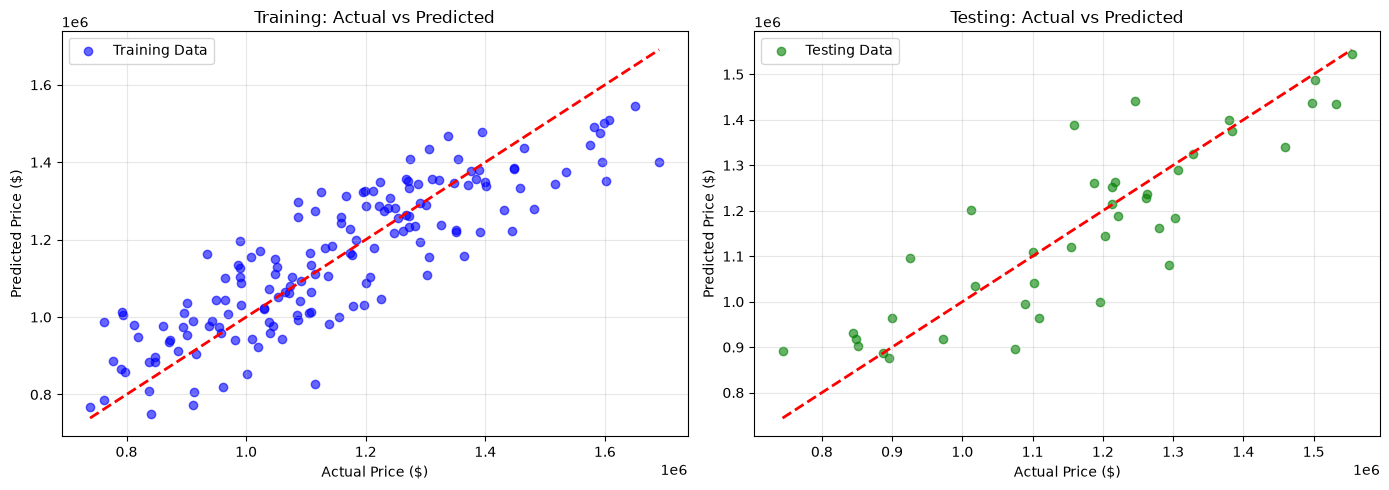


✅ Model Evaluation Complete!


In [ ]:
# Model Evaluation

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n📊 TRAINING SET METRICS:")
print(f"  MAE (Mean Absolute Error):  ${train_mae:,.2f}")
print(f"  RMSE (Root Mean Sq Error):  ${train_rmse:,.2f}")
print(f"  R² Score:                   {train_r2:.4f}")

print("\n📊 TESTING SET METRICS:")
print(f"  MAE (Mean Absolute Error):  ${test_mae:,.2f}")
print(f"  RMSE (Root Mean Sq Error):  ${test_rmse:,.2f}")
print(f"  R² Score:                   {test_r2:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.6, label='Training Data', color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Training: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.6, label='Testing Data', color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price ($)')
axes[1].set_ylabel('Predicted Price ($)')
axes[1].set_title('Testing: Actual vs Predicted')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Model Evaluation Complete!")

In [ ]:
# Sample Predictions - How to Use the Model

print("=" * 50)
print("SAMPLE PREDICTIONS")
print("=" * 50)

# Example 1: Large house close to city center
sample_house_1 = pd.DataFrame({
    'square_feet': [3500],
    'bedrooms': [4],
    'bathrooms': [3],
    'age_years': [10],
    'garage_spaces': [2],
    'distance_to_center': [2.5],
    'location_score': [75]
})

pred_1 = model.predict(sample_house_1)[0]
print(f"\n🏠 House 1 (Large, close to center):")
print(f"   Square Feet: 3,500")
print(f"   Bedrooms: 4")
print(f"   Distance from center: 2.5 km")
print(f"   💰 Predicted Price: ${pred_1:,.2f}")

# Example 2: Small house far from center
sample_house_2 = pd.DataFrame({
    'square_feet': [1500],
    'bedrooms': [2],
    'bathrooms': [1],
    'age_years': [30],
    'garage_spaces': [1],
    'distance_to_center': [8.0],
    'location_score': [30]
})

pred_2 = model.predict(sample_house_2)[0]
print(f"\n🏠 House 2 (Small, far from center):")
print(f"   Square Feet: 1,500")
print(f"   Bedrooms: 2")
print(f"   Distance from center: 8 km")
print(f"   💰 Predicted Price: ${pred_2:,.2f}")

print(f"\n✅ Predictions Complete!")